<a href="https://colab.research.google.com/github/ZuhaibAkhtarKhan/3Bins-HackGitV2/blob/main/trash_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.0 MB/s eta 0:00:00


In [ ]:
import zipfile
from pathlib import Path

In [ ]:
with zipfile.ZipFile('archive(2).zip','r') as zip_file:
  print("extracting...")
  zip_file.extractall("/content")

extracting...


In [ ]:
from ultralytics import YOLO

# Load small pretrained model (best for hackathon)
model = YOLO("yolov8n.pt")

# Train
model.train(
    data="/content/trash_data/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/trash_data/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7bcd7b967890>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

In [ ]:
from google.colab import files
files.download('/content/runs/detect/train/weights/best.pt')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from ultralytics import YOLO
import cv2
from matplotlib import pyplot as plt
import random

# Load your trained model
model = YOLO("/content/runs/detect/train/weights/best.pt")

# Load a test image
targ_dir = "/content/trash_data/test/images"
img_paths = list(Path(targ_dir).glob("/*.jpg"))
sample_img = random.sample(img_paths,3)

for img_path in sample_img:
  # Run inference
  results = model.predict(img_path, conf=0.6)  # confidence threshold 0.6

  # Plot results
  results[0].plot()
  plt.imshow(results[0].plot())
  plt.axis('off')
  plt.show()

  # Print detected classes and bounding boxes
  print(results[0].boxes.data)


NotImplementedError: Non-relative patterns are unsupported


image 1/1 /content/trash_data/test/images/paper1125_jpg.rf.8f5c9fa5a238d94950371aadc49e5c61.jpg: 640x640 1 PAPER, 16.7ms
Speed: 4.5ms preprocess, 16.7ms inference, 2.7ms postprocess per image at shape (1, 3, 640, 640)


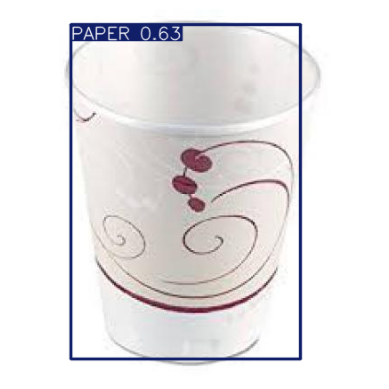

Class: 4, Confidence: 0.63, Box: [68, 18, 326, 394]

image 1/1 /content/trash_data/test/images/paper2279_jpg.rf.769904fd52f03f159ebc816994ffaa2b.jpg: 640x640 1 CARDBOARD, 14.9ms
Speed: 5.8ms preprocess, 14.9ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 640)


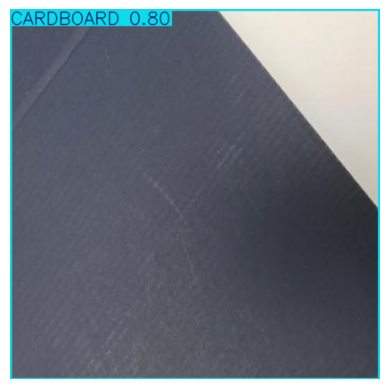

Class: 1, Confidence: 0.80, Box: [0, 0, 416, 416]

image 1/1 /content/trash_data/test/images/metal310_jpg.rf.b3569ee615042585a0952c3acd0f36d2.jpg: 640x640 1 METAL, 13.5ms
Speed: 4.5ms preprocess, 13.5ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 640)


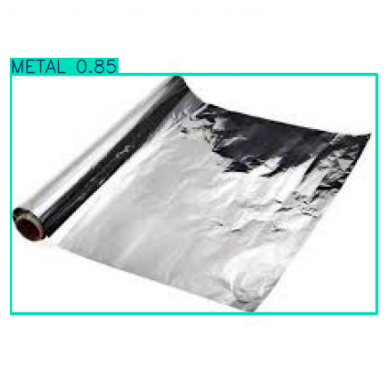

Class: 3, Confidence: 0.85, Box: [0, 73, 413, 342]

image 1/1 /content/trash_data/test/images/metal283_jpg.rf.77085f5929135008258b4aeb2ed3086c.jpg: 640x640 4 METALs, 12.9ms
Speed: 4.7ms preprocess, 12.9ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 640)


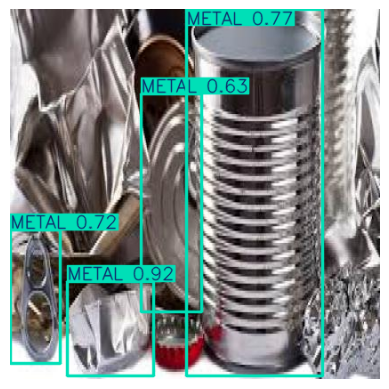

Class: 3, Confidence: 0.92, Box: [64, 306, 161, 412]
Class: 3, Confidence: 0.77, Box: [199, 0, 352, 413]
Class: 3, Confidence: 0.72, Box: [0, 249, 57, 398]
Class: 3, Confidence: 0.63, Box: [148, 95, 215, 340]

image 1/1 /content/trash_data/test/images/metal1102_jpg.rf.a7a2329c2dd38a0b268eed4d52e7f7aa.jpg: 640x640 1 METAL, 12.3ms
Speed: 5.1ms preprocess, 12.3ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)


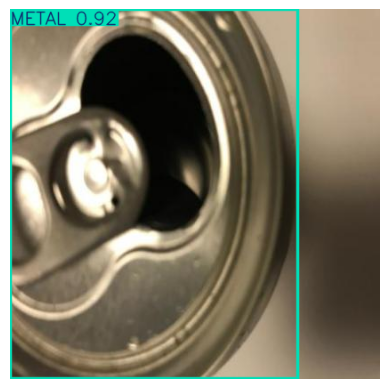

Class: 3, Confidence: 0.92, Box: [0, 0, 324, 416]

image 1/1 /content/trash_data/test/images/plastic29_jpg.rf.adc5f9f51e64a89a4e92f57799a0c250.jpg: 640x640 1 PLASTIC, 14.5ms
Speed: 4.0ms preprocess, 14.5ms inference, 2.7ms postprocess per image at shape (1, 3, 640, 640)


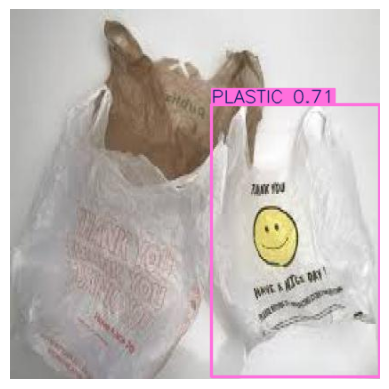

Class: 5, Confidence: 0.71, Box: [226, 108, 416, 413]

image 1/1 /content/trash_data/test/images/plastic500_jpg.rf.1418aca53e6d65c360dad26c97ddb7d4.jpg: 640x640 1 PLASTIC, 14.1ms
Speed: 3.8ms preprocess, 14.1ms inference, 2.7ms postprocess per image at shape (1, 3, 640, 640)


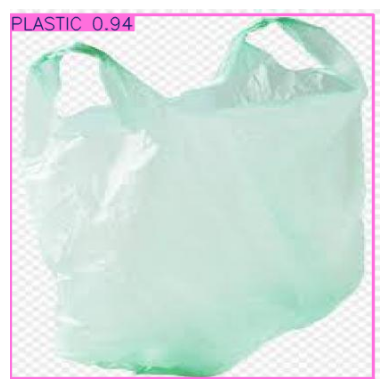

Class: 5, Confidence: 0.94, Box: [1, 7, 408, 416]

image 1/1 /content/trash_data/test/images/paper1608_jpg.rf.94afe671c0e7089d1732d8f859686de2.jpg: 640x640 1 PAPER, 14.1ms
Speed: 6.8ms preprocess, 14.1ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 640)


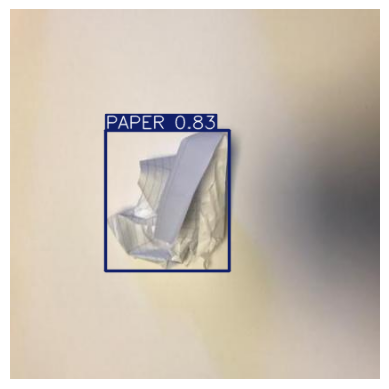

Class: 4, Confidence: 0.83, Box: [107, 136, 246, 295]

image 1/1 /content/trash_data/test/images/paper991_jpg.rf.3cbe06397af5ddb2f429340fedc676e3.jpg: 640x640 1 PAPER, 16.5ms
Speed: 4.8ms preprocess, 16.5ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 640)


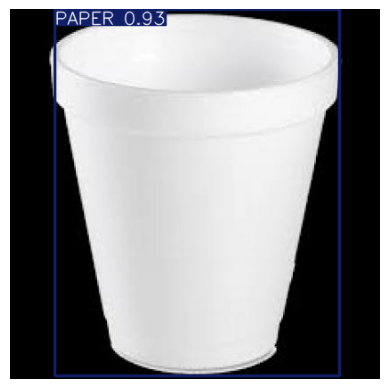

Class: 4, Confidence: 0.93, Box: [51, 0, 371, 412]


In [ ]:
from ultralytics import YOLO
import cv2
from matplotlib import pyplot as plt
import random
from pathlib import Path

# Load your trained model
model = YOLO("/content/runs/detect/train/weights/best.pt")

# Load test images
targ_dir = "/content/trash_data/test/images"
img_paths = list(Path(targ_dir).glob("*.jpg"))
sample_imgs = random.sample(img_paths, 9)

for img_path in sample_imgs:
    # Run inference
    results = model.predict(img_path, conf=0.6)

    # Plot results
    img_with_boxes = results[0].plot()
    plt.imshow(cv2.cvtColor(img_with_boxes, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

    # Print detected classes and bounding boxes
    for box in results[0].boxes.data:
        x1, y1, x2, y2, conf, cls = box
        print(f"Class: {int(cls)}, Confidence: {conf:.2f}, Box: [{x1:.0f}, {y1:.0f}, {x2:.0f}, {y2:.0f}]")



image 1/1 /content/IMG_20260214_013547_577.jpg: 640x480 1 PLASTIC, 9.1ms
Speed: 3.4ms preprocess, 9.1ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 480)


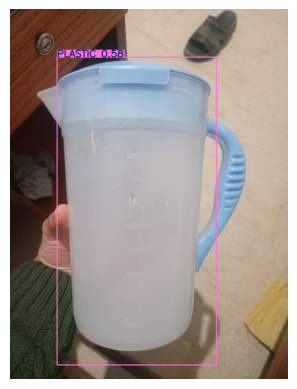

Class: 5, Confidence: 0.58, Box: [585, 599, 2566, 4432]


In [ ]:
results = model.predict("/content/IMG_20260214_013547_577.jpg", imgsz=640, conf=0.5)


# Plot results
img_with_boxes = results[0].plot()
plt.imshow(cv2.cvtColor(img_with_boxes, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

# Print detected classes and bounding boxes
for box in results[0].boxes.data:
  x1, y1, x2, y2, conf, cls = box
  print(f"Class: {int(cls)}, Confidence: {conf:.2f}, Box: [{x1:.0f}, {y1:.0f}, {x2:.0f}, {y2:.0f}]")


In [ ]:
# Run validation on your dataset
metrics = model.val(data="/content/trash_data/data.yaml")

# Confusion matrix
metrics.confusion_matrix.plot()

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1173.8±513.8 MB/s, size: 26.6 KB)
val: Scanning /content/trash_data/valid/labels.cache... 2098 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2098/2098 628.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 132/132 5.3it/s 24.9s
                   all       2098      18916      0.621      0.436       0.52      0.359
         BIODEGRADABLE        676      13637      0.875      0.398      0.615      0.351
             CARDBOARD        438       1292      0.778      0.462      0.604      0.458
                 GLASS        805       2380      0.883       0.67      0.797      0.586
                 METAL        398       1360      0.749      0.561      0.666      0.449
                 PAPER         15         33     0.0516     0.0606     0.0712     0.0676
               PLASTIC         

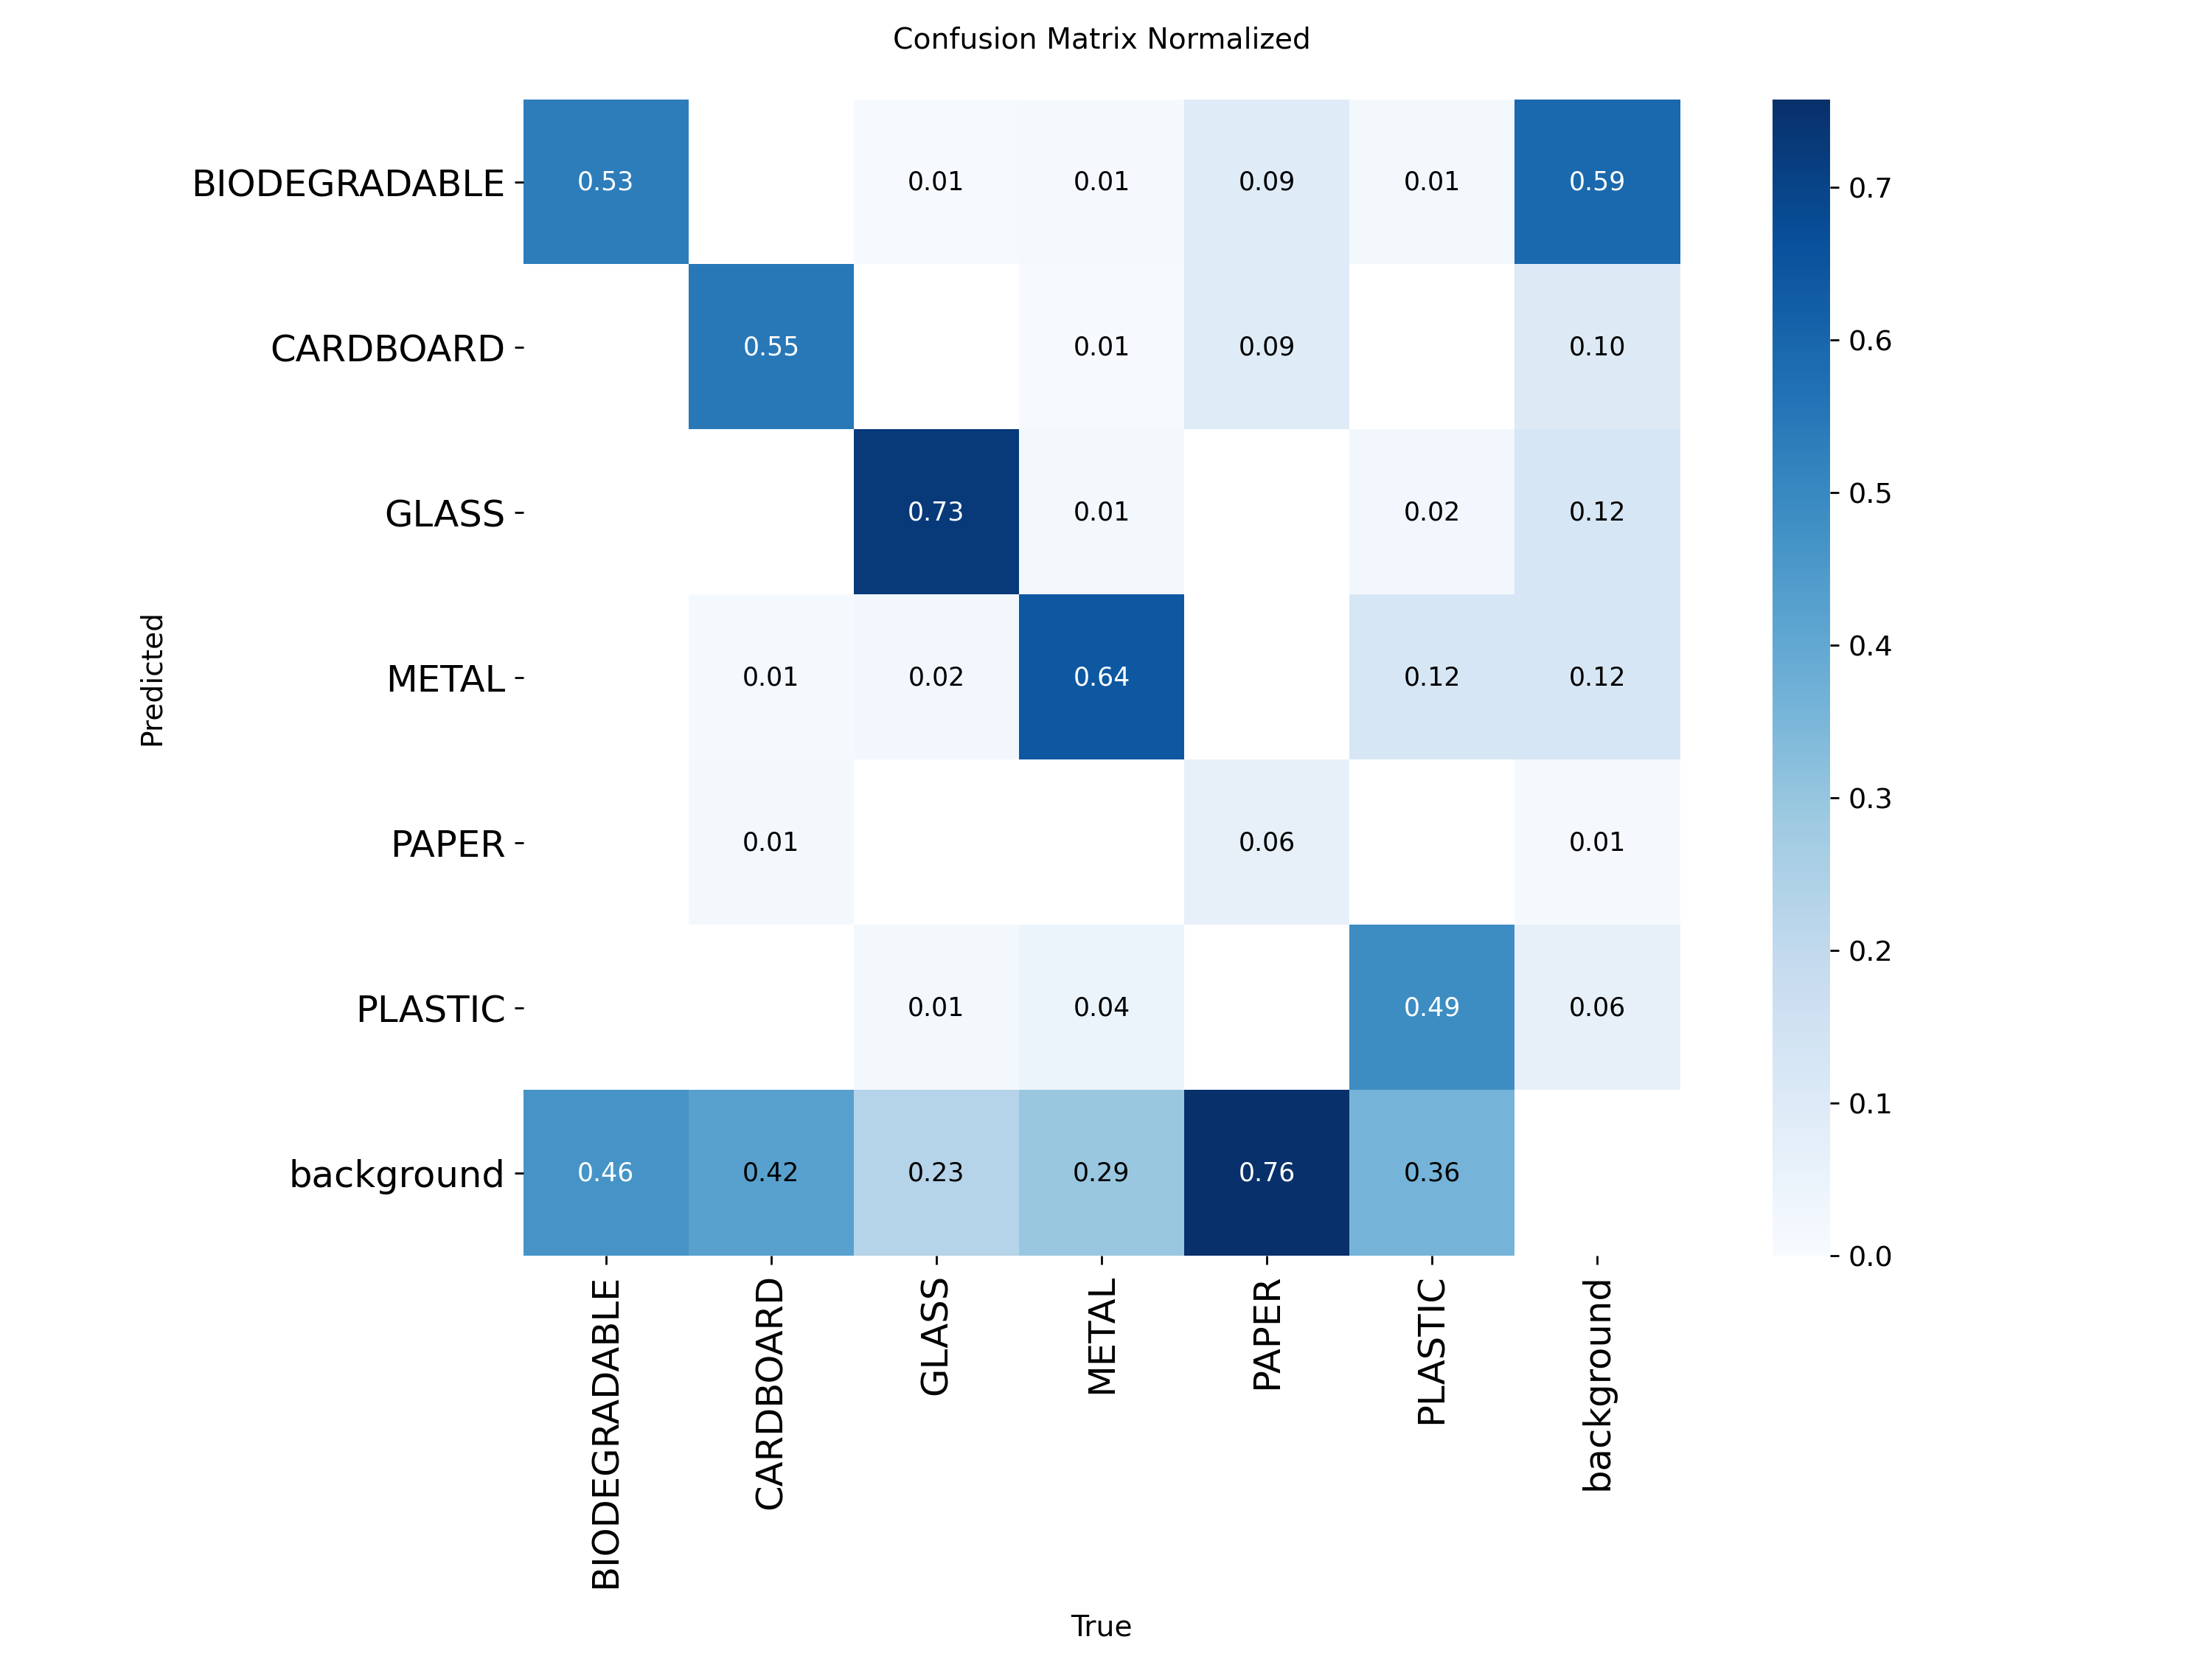

In [ ]:
from IPython.display import Image, display

# Assuming the confusion matrix is saved as 'confusion_matrix_normalized.png' in the latest run directory
# You can adjust the path if the filename or directory is different
image_path = '/content/runs/detect/val2/confusion_matrix_normalized.png'
display(Image(filename=image_path))

In [ ]:
from ultralytics import YOLO
import cv2
from matplotlib import pyplot as plt
import random
from pathlib import Path

# Load your trained model
model = YOLO("/content/best.pt")
# 0 = default webcam
model.predict(source=0, conf=0.5)

# Load test images
# targ_dir = "/content/trash_data/test/images"
# img_paths = list(Path(targ_dir).glob("*.jpg"))
# sample_imgs = random.sample(img_paths, 9)

# for img_path in sample_imgs:
#     # Run inference
#     results = model.predict(img_path, conf=0.6)

#     # Plot results
#     img_with_boxes = results[0].plot()
#     plt.imshow(cv2.cvtColor(img_with_boxes, cv2.COLOR_BGR2RGB))
#     plt.axis('off')
#     plt.show()

#     # Print detected classes and bounding boxes
#     for box in results[0].boxes.data:
#         x1, y1, x2, y2, conf, cls = box
#         print(f"Class: {int(cls)}, Confidence: {conf:.2f}, Box: [{x1:.0f}, {y1:.0f}, {x2:.0f}, {y2:.0f}]")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.



NotImplementedError: 'source=0' webcam not supported in Colab and Kaggle notebooks. Try running 'source=0' in a local environment.

In [ ]:
from ultralytics import YOLO

# Load your trained model
model = YOLO("/content/best.pt")

# Run validation on your dataset
metrics = model.val(data="/content/GARBAGE CLASSIFICATION/data.yaml")


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 468.6±310.9 MB/s, size: 20.5 KB)
val: Scanning /content/GARBAGE CLASSIFICATION/valid/labels... 2098 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2098/2098 1.4Kit/s 1.5s
val: New cache created: /content/GARBAGE CLASSIFICATION/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 132/132 5.7it/s 23.2s
                   all       2098      18916      0.621      0.436       0.52      0.359
         BIODEGRADABLE        676      13637      0.875      0.398      0.615      0.351
             CARDBOARD        438       1292      0.778      0.462      0.604      0.458
                 GLASS        805       2380      0.883       0.67      0.797      0.586
                 METAL        398       1360       

In [ ]:
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)


mAP50: 0.5203538252554963
mAP50-95: 0.35866933292698255
Precision: 0.6208111286195016
Recall: 0.43572149431131363
